正在加载数据...
开始训练...
Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9004 - loss: 0.3264 - val_accuracy: 0.9817 - val_loss: 0.0605
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9681 - loss: 0.1071 - val_accuracy: 0.9865 - val_loss: 0.0432
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9765 - loss: 0.0794 - val_accuracy: 0.9888 - val_loss: 0.0373


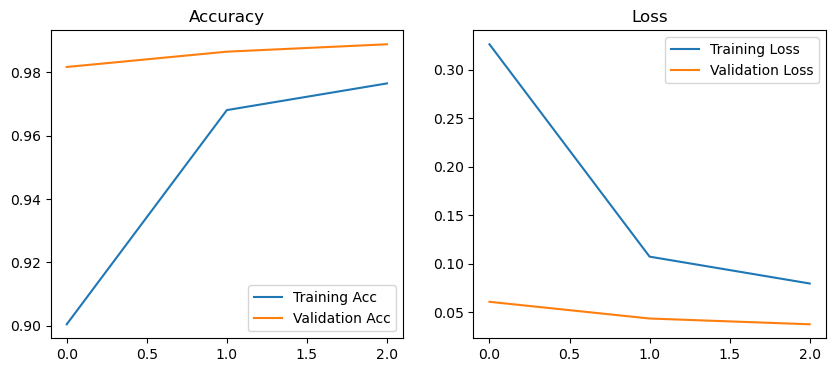

展示预测结果...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


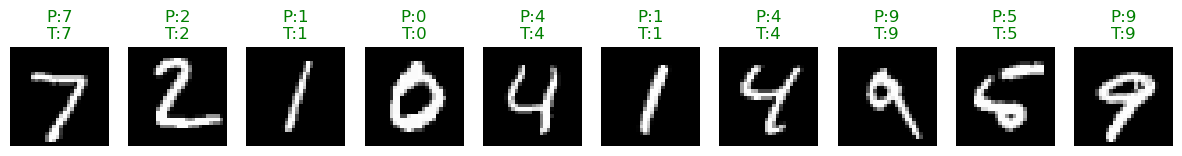

In [4]:
import tensorflow as tf
from tensorflow.keras import backend
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

# 【重要修改】强制重置数据格式为 channels_last (默认格式)
# 这样 (28, 28, 1) 就会被正确识别为 28x28 像素, 1个颜色通道
backend.set_image_data_format('channels_last')

# 1. 加载数据
print("正在加载数据...")
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# 保存原始图片用于显示
X_test_orig = X_test

# 2. 预处理
# 形状: (样本数, 宽, 高, 通道)
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

# 3. 构建模型
model = Sequential([
    # 第一层卷积，注意 input_shape 对应 (28, 28, 1)
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# 4. 训练
print("开始训练...")
history = model.fit(X_train, y_train_cat, 
                    epochs=3, # 先练3轮看效果
                    batch_size=128, 
                    validation_split=0.1, 
                    verbose=1)

# 5. 可视化：训练曲线
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Acc')
plt.plot(history.history['val_accuracy'], label='Validation Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.show()

# 6. 可视化：预测测试
def visualize_results(model, X_test, y_test, X_test_orig, num=10):
    preds = model.predict(X_test[:num])
    pred_labels = np.argmax(preds, axis=1)
    
    plt.figure(figsize=(15, 3))
    for i in range(num):
        plt.subplot(1, num, i+1)
        plt.imshow(X_test_orig[i], cmap='gray')
        color = 'green' if pred_labels[i] == y_test[i] else 'red'
        plt.title(f"P:{pred_labels[i]}\nT:{y_test[i]}", color=color)
        plt.axis('off')
    plt.show()

print("展示预测结果...")
visualize_results(model, X_test, y_test, X_test_orig)